<a href="https://colab.research.google.com/github/Kotoal/Study/blob/main/CNN_2_tnayin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving kaggle.json to kaggle (2).json
Dataset URL: https://www.kaggle.com/datasets/swaroopkml/cifar10-pngs-in-folders
License(s): unknown
cifar10-pngs-in-folders.zip: Skipping, found more recently modified local copy (use --force to force download)
replace cifar10/cifar10/test/airplane/0001.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
Train samples :: 40000
Validation samples :: 10000
Test samples :: 10000
------------------------------------
Number of classes :: 10
Classes list ::
0 :։ class airplane
1 :։ class automobile
2 :։ class bird
3 :։ class cat
4 :։ class deer
5 :։ class dog
6 :։ class frog
7 :։ class horse
8 :։ class ship
9 :։ class truck
Image shape :: torch.Size([3, 224, 224])


Epoch 1/5 | Train Loss: 0.4245 | Val Loss: 0.2935 | Train Acc: 85.61% | Val Acc: 89.93%


Epoch 2/5 | Train Loss: 0.1725 | Val Loss: 0.2769 | Train Acc: 94.09% | Val Acc: 91.11%


Epoch 3/5 | Train Loss: 0.0883 | Val Loss: 0.2165 | Train Acc: 97.01% | Val Acc: 93.17%


Epoch 4/5 | Train Loss: 0.0577 | Val Loss: 0.2677 | Train Acc: 98.00% | Val Acc: 92.58%


Epoch 5/5 | Train Loss: 0.0454 | Val Loss: 0.2221 | Train Acc: 98.48% | Val Acc: 93.63%


Final Test Accuracy: 93.45%


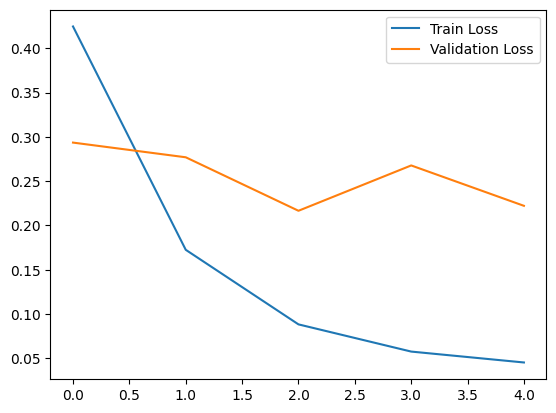

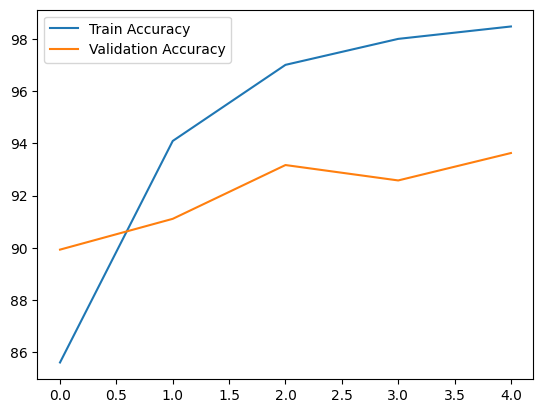

              precision    recall  f1-score   support

    airplane       0.95      0.94      0.94      1000
  automobile       0.97      0.96      0.96      1000
        bird       0.91      0.93      0.92      1000
         cat       0.87      0.85      0.86      1000
        deer       0.89      0.97      0.93      1000
         dog       0.91      0.88      0.89      1000
        frog       0.97      0.96      0.96      1000
       horse       0.97      0.94      0.95      1000
        ship       0.96      0.97      0.96      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     10000



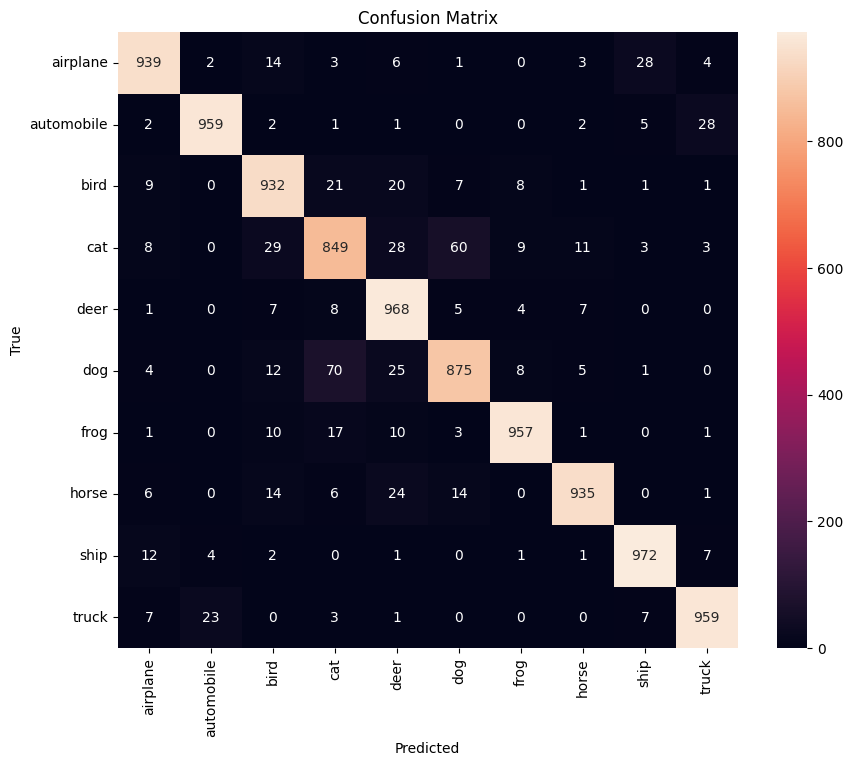

In [9]:
!pip install kaggle -q

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d swaroopkml/cifar10-pngs-in-folders
!unzip -q cifar10-pngs-in-folders.zip

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torchvision.datasets import ImageFolder
from torch.utils.data import random_split
from tqdm import tqdm

augment_pipeline = transforms.Compose([
    transforms.Resize(224),
    transforms.RandomCrop(224, padding=28),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

eval_pipeline = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

source_dataset = ImageFolder(root="/content/cifar10/cifar10/train", transform=None)
n_train        = int(0.8 * len(source_dataset))
n_val          = len(source_dataset) - n_train
split_train, split_val = random_split(source_dataset, [n_train, n_val])

split_train.dataset.transform = augment_pipeline
split_val.dataset.transform   = eval_pipeline

holdout_dataset = ImageFolder(root="/content/cifar10/cifar10/test", transform=eval_pipeline)

print("Train samples ::", len(split_train))
print("Validation samples ::", len(split_val))
print("Test samples ::", len(holdout_dataset))
print("------------------------------------")

label_names = split_train.dataset.classes
print("Number of classes ::", len(label_names))
print("Classes list ::")
for idx, name in enumerate(label_names):
    print(f"{idx} :։ class {name}")

sample_img, sample_lbl = split_train[0]
print("Image shape ::", sample_img.shape)

loader_train = DataLoader(split_train,      batch_size=64, shuffle=True)
loader_val   = DataLoader(split_val,        batch_size=64, shuffle=False)
loader_test  = DataLoader(holdout_dataset,  batch_size=64, shuffle=False)

backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
backbone.fc = nn.Linear(backbone.fc.in_features, 10)

compute_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
backbone = backbone.to(compute_device)

for p in backbone.parameters():
    p.requires_grad = True

loss_fn  = nn.CrossEntropyLoss()
opt      = optim.SGD(backbone.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
lr_sched = optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.1)

total_epochs = 5
epoch_train_loss, epoch_val_loss = [], []
epoch_train_acc,  epoch_val_acc  = [], []
top_val_acc = 0

for ep in range(total_epochs):
    backbone.train()
    batch_loss = 0
    hits = 0
    seen = 0

    loop = tqdm(loader_train, desc=f"Epoch {ep+1}/{total_epochs} [Train]", leave=False)
    for imgs, targets in loop:
        imgs, targets = imgs.to(compute_device), targets.to(compute_device)
        opt.zero_grad()
        logits = backbone(imgs)
        step_loss = loss_fn(logits, targets)
        step_loss.backward()
        opt.step()
        batch_loss += step_loss.item()
        _, preds = logits.max(1)
        seen += targets.size(0)
        hits += preds.eq(targets).sum().item()
        loop.set_postfix(loss=f"{step_loss.item():.4f}", acc=f"{100*hits/seen:.2f}%")

    epoch_train_loss.append(batch_loss / len(loader_train))
    epoch_train_acc.append(100 * hits / seen)

    backbone.eval()
    val_batch_loss = 0
    val_hits = 0
    val_seen = 0

    loop_val = tqdm(loader_val, desc=f"Epoch {ep+1}/{total_epochs} [Val]  ", leave=False)
    with torch.no_grad():
        for imgs, targets in loop_val:
            imgs, targets = imgs.to(compute_device), targets.to(compute_device)
            logits = backbone(imgs)
            step_loss = loss_fn(logits, targets)
            val_batch_loss += step_loss.item()
            _, preds = logits.max(1)
            val_seen += targets.size(0)
            val_hits += preds.eq(targets).sum().item()

    epoch_val_loss.append(val_batch_loss / len(loader_val))
    epoch_val_acc.append(100 * val_hits / val_seen)

    if epoch_val_acc[-1] > top_val_acc:
        top_val_acc = epoch_val_acc[-1]
        torch.save(backbone.state_dict(), "checkpoint_best.pth")

    lr_sched.step()
    print(f"Epoch {ep+1}/{total_epochs} | "
          f"Train Loss: {epoch_train_loss[-1]:.4f} | "
          f"Val Loss: {epoch_val_loss[-1]:.4f} | "
          f"Train Acc: {epoch_train_acc[-1]:.2f}% | "
          f"Val Acc: {epoch_val_acc[-1]:.2f}%")

backbone.load_state_dict(torch.load("checkpoint_best.pth"))
backbone.eval()
test_hits = 0
test_seen = 0

with torch.no_grad():
    for imgs, targets in tqdm(loader_test, desc="Testing", leave=False):
        imgs, targets = imgs.to(compute_device), targets.to(compute_device)
        logits = backbone(imgs)
        _, preds = logits.max(1)
        test_seen += targets.size(0)
        test_hits += preds.eq(targets).sum().item()

final_acc = 100 * test_hits / test_seen
print(f"Final Test Accuracy: {final_acc:.2f}%")

plt.plot(epoch_train_loss, label="Train Loss")
plt.plot(epoch_val_loss,   label="Validation Loss")
plt.legend()
plt.show()

plt.plot(epoch_train_acc, label="Train Accuracy")
plt.plot(epoch_val_acc,   label="Validation Accuracy")
plt.legend()
plt.show()

collected_preds  = []
collected_labels = []
backbone.eval()

with torch.no_grad():
    for imgs, targets in loader_test:
        imgs = imgs.to(compute_device)
        logits = backbone(imgs)
        batch_preds = logits.argmax(dim=1).cpu().numpy()
        collected_preds.extend(batch_preds)
        collected_labels.extend(targets.numpy())

print(classification_report(collected_labels, collected_preds, target_names=label_names))

import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

conf_mat = confusion_matrix(collected_labels, collected_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

torch.save(backbone.state_dict(), "resnet18_cifar10_v2.pth")

Saving images.jpg to images.jpg


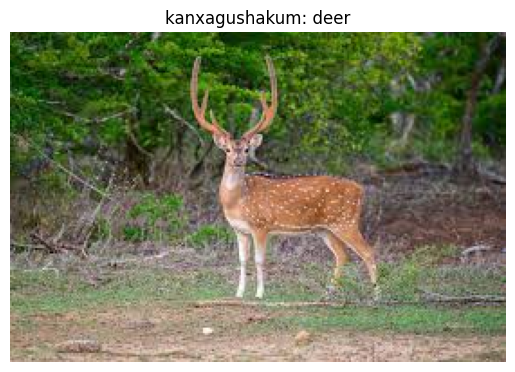

Modely mtatum e vor sa : deer


In [10]:
from torchvision import models, transforms
import torch
import torch.nn as nn
from PIL import Image
import matplotlib.pyplot as plt

backbone = models.resnet18()
backbone.fc = nn.Linear(512, 10)
backbone.load_state_dict(torch.load("resnet18_cifar10_v2.pth"))
backbone.eval()

label_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

from google.colab import files
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = Image.open(img_path).convert("RGB")
tensor = transform(img).unsqueeze(0)

with torch.no_grad():
    output = backbone(tensor)
    pred = output.argmax(dim=1).item()

plt.imshow(img)
plt.title(f"kanxagushakum: {label_names[pred]}")
plt.axis("off")
plt.show()

print(f"Modely mtatum e vor sa : {label_names[pred]}")